## Black Scholes functions for option prices
## Numerical processing of financial data 

Stefano De Marco

**Objective.**
The goal of this notebook is to implement the explicit formulas for the Black-Scholes price, delta, vega and gamma for call and put options, and to inspect their behavior.

In [1]:
import numpy as np

### 1. The Black-Scholes Call price and its Delta

$\blacktriangleright$ We wish to implement the explicit Black-Scholes formula for the call option price $P^{\mathrm{Call}}(t,S)$ and its delta $\delta(t,S)=\partial_S P^{\mathrm{Call}}(t,S)$ obtained in Exercise sheet \#2, and observe their behavior.

Recall that:
$$
\begin{aligned}
&P^{\mathrm{Call}}(t,S) = S \, N (d_1) - K e^{-r(T-t)} N(d_2)
\\
&\delta(t,S) = \partial_S P^{\mathrm{Call}}(t,S) = N(d_1),
\end{aligned}
$$

where 
$$
d_1 = \frac 1{\sigma \sqrt{T-t}} \log \frac{S \,e^{r(T-t)}}K + \frac 12 \sigma \sqrt{T-t}, \qquad
d_2 = d_1 - \sigma \sqrt{T-t},
$$
and $N(x) = \int_{-\infty}^x \frac 1{\sqrt{2 \pi}} e^{-\frac{y^2} 2} dy$ is the Gaussian cdf, implemented by the function _norm.cdf()_ in the library _scipy.stats_.

$\blacktriangleright$ __TO DO__: complete the evaluation of the call option price and delta in the cell below.

In [3]:
import scipy.stats as sps

def Call_BS(t, S, T, K, r, sigma):
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    d1 = 1/sigma_sqrt_time * np.log(S * np.exp(r * (T - t)) / K) + 0.5 * sigma_sqrt_time
    d2 = d1 - sigma_sqrt_time
    price = S * sps.norm.cdf(d1) - K * np.exp(-r * (T - t)) * sps.norm.cdf(d2)
    return price

def delta_BS(t, S, T, K, r, sigma):
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    d1 = 1/sigma_sqrt_time * np.log(S * np.exp(r * (T - t)) / K) + 0.5 * sigma_sqrt_time
    delta = sps.norm.cdf(d1)
    return delta

Below, we do some plotting, so to observe the behavior of the price and delta for a call option.

In [5]:
# call option parameters
maturity = 1. # expressed in years
K = 115

# Interest rate 
r = 0.02

# BS parameter sigma
sigma = 0.3

# Possible values for the underlying asset price : a grid of points ranging from K/3 to 2*K
number_points = 200
S = np.linspace(K/3, 2*K, 200)

# Values of the date t at which we observe the option price and the option delta
dates = np.array([0., 1/2, maturity-1/12]) #today, in six months, one month before maturity
number_dates = dates.size

# These two arrays will stock the value of the price and delta for the different dates
price = np.zeros(number_dates * number_points).reshape(number_dates, number_points)
delta = np.zeros(number_dates * number_points).reshape(number_dates, number_points)

for i in range(number_dates):
    t = dates[i]
    
    price_t = Call_BS(t, S, maturity, K, r, sigma)
    delta_t = delta_BS(t, S, maturity, K, r, sigma)
    
    price[i] = price_t
    delta[i] = delta_t

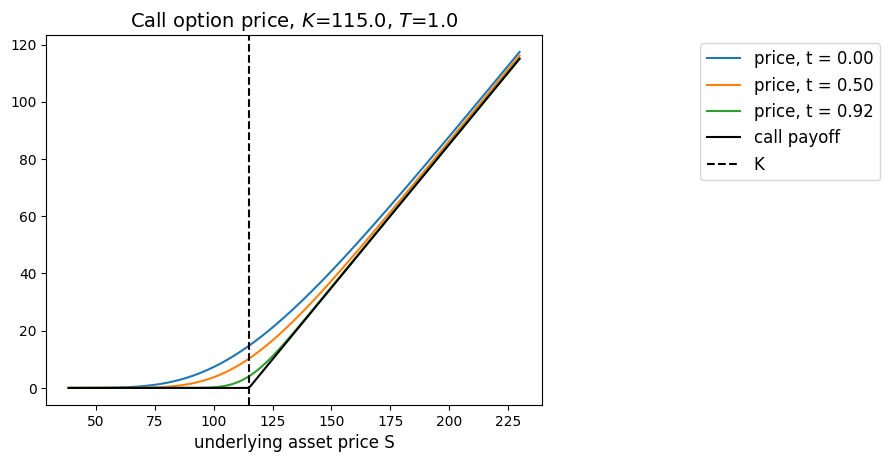

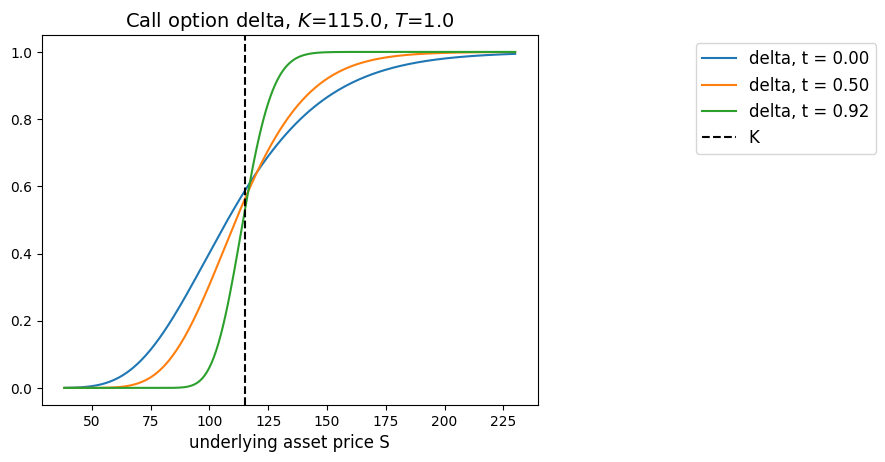

In [6]:
###############
## Plotting
###############
import matplotlib.pyplot as plt

#########
## price 
#########

plt.figure()

for i in range(number_dates):
    plt.plot(S, price[i], label="price, t = %1.2f" %dates[i])

# Also plot the option payoff
plt.plot(S, np.maximum(S - K, 0), label="call payoff", color="k")
plt.axvline(K, color="k", linestyle = "--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Call option price, $K$=%1.1f, $T$=%1.1f" %(K,maturity), fontsize=14)
plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)

#########
## delta 
#########
plt.figure()

for i in range(number_dates):
    plt.plot(S, delta[i], label="delta, t = %1.2f" %dates[i])
    
plt.axvline(K, color="k", linestyle = "--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Call option delta, $K$=%1.1f, $T$=%1.1f" %(K,maturity), fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)
plt.show()

### 2. Black-Scholes Gamma and Vega

We now wish to inspect the behavior of the Black-Scholes vega $\partial_\sigma P^{\mathrm{Call}}(t,S)$ and gamma $\partial_{SS} \sigma P^{\mathrm{Call}}(t,S)$.

Recall that:
$$
\mathrm{Vega}(t, S)
= \partial_\sigma P^{\mathrm{Call}}(t,S)
= S \, \sqrt{T-t} \, n(d_1)
$$
where $n(x) = \frac 1{\sqrt{2 \pi}} e^{-\frac{x^2}2}$.

$\blacktriangleright$ __TO DO__: show that the following expression holds for the call option gamma:
$$
\mathrm{Gamma}(t, S)
= \partial_{SS} P^{\mathrm{Call}}(t,S)
= \frac{n(d_1)}{S \, \sigma \sqrt{T-t}}
$$

$\blacktriangleright$ __TO DO__: complete the evaluation of the call option vega and gamma in the cell below.

In [7]:
def Vega(t, S, T, K, r, sigma):
    tau = T - t
    sigma_sqrt_time = sigma * np.sqrt(tau)
    d1 = 1/sigma_sqrt_time * np.log(S * np.exp(r * tau) / K) + 0.5 * sigma_sqrt_time
    vega = S * sps.norm.pdf(d1) * np.sqrt(tau)
    
    return vega

def Gamma(t, S, T, K, r, sigma):
    sigma_sqrt_time = sigma * np.sqrt(T - t)
    d1 = 1/sigma_sqrt_time * np.log(S * np.exp(r * (T - t)) / K) + 0.5 * sigma_sqrt_time
    gamma = sps.norm.pdf(d1) / (S * sigma_sqrt_time)

    return gamma

$\bullet$ Plot the values of gamma and vega over a grid of values of $S$, for different observation dates (as done above for the option price and delta).

In [8]:
# call option parameters
maturity = 1. # expressed in years
K = 115

# Interest rate 
r = 0.02

# BS parameter sigma
sigma = 0.3

# Possible values for the underlying asset price : a grid of points ranging from K/3 to 2*K
number_points = 200
S = np.linspace(K/3, 2*K, 200)

# Values of the date t at which we observe the option price and the option delta
dates = np.array([0., 1/2, 1-1/12]) #today, in six months, one month before maturity
number_dates = dates.size

# These two arrays will stock the values of the gamma and vega for the different dates
vega = np.zeros(number_dates * number_points).reshape(number_dates, number_points)
gamma = np.zeros(number_dates * number_points).reshape(number_dates, number_points)

for i in range(number_dates):
    t = dates[i]
    
    vega_t = Vega(t, S, maturity, K, r, sigma)
    gamma_t = Gamma(t, S, maturity, K, r, sigma)
    
    vega[i] = vega_t
    gamma[i] = gamma_t

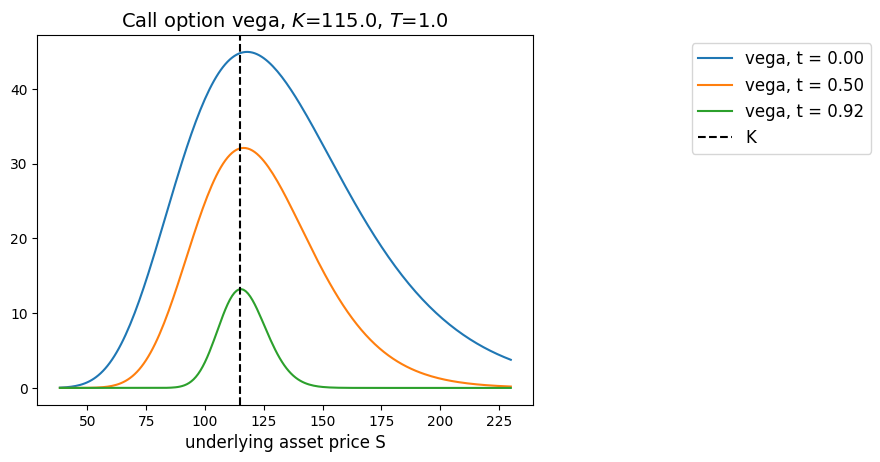

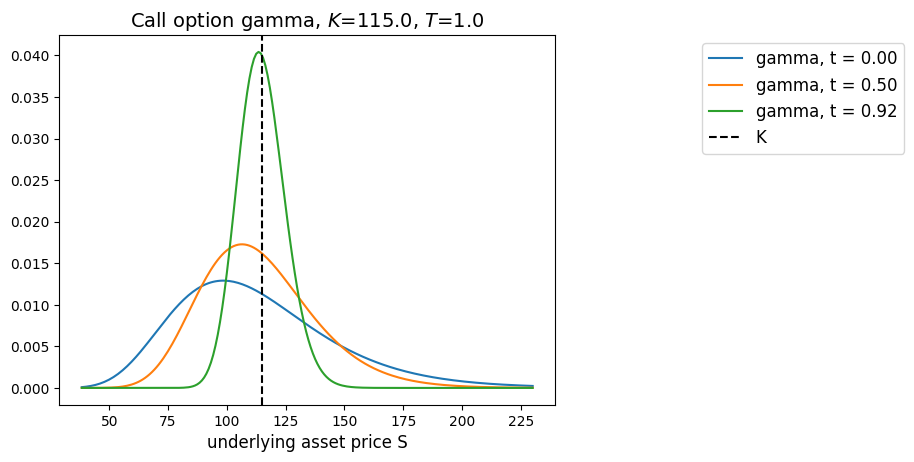

In [9]:
#########
## Vega
#########

plt.figure()

for i in range(number_dates):
    plt.plot(S, vega[i], label="vega, t = %1.2f" %dates[i])
    
plt.axvline(K, color="k", linestyle = "--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Call option vega, $K$=%1.1f, $T$=%1.1f" %(K,maturity), fontsize=14)
plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)

#########
## Gamma 
#########
plt.figure()

for i in range(number_dates):
    plt.plot(S, gamma[i], label="gamma, t = %1.2f" %dates[i])
    
plt.axvline(K, color="k", linestyle = "--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Call option gamma, $K$=%1.1f, $T$=%1.1f" %(K,maturity), fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)
plt.show()

### 3. The Black-Scholes formulas for the Put option

$\blacktriangleright$ Recall the explicit Black-Scholes formulas the put option price and delta:

$$
\begin{aligned}
&P^{\mathrm{Put}}(t,S) = K e^{-r(T-t)} N(-d_2) - S \, N (-d_1)
\\
&\delta^{\mathrm{Put}}(t,S) = \partial_S P^{\mathrm{Put}}(t,S) = -N(-d_1),
\end{aligned}
$$

Also recall that call and put prices are linked via the so-called put-call parity relationship (see Exercise sheet 2)

$$
P^{\mathrm{Call}}(t,S) - P^{\mathrm{Put}}(t,S) = S - e^{-r(T-t)} K
$$

so that call and put options share the same Gamma $\partial_{SS} P^{\mathrm{Call}}(t,S) = \partial_{SS} P^{\mathrm{Put}}(t,S) = \frac{n(d_1)}{S \, \sigma \sqrt{T-t}}$ and the same Vega $\partial_{\sigma} P^{\mathrm{Call}}(t,S) = \partial_{\sigma} P^{\mathrm{Put}}(t,S)$.

$\blacktriangleright$ __TO DO__: in the function below, we aim at implementing the call and put option price, delta and gamma, all at once.

In [ ]:
def Black_Scholes_function(t, S, T, K, r, sigma, flag):
    """
    flag : boolean, flag = 1 for a call option and flag = 0 for a put option
    """
    sigma_sqrt_time = sigma * np.sqrt(T - t)

    d_1 = (np.log(S/K) + r*(T-t)) / sigma_sqrt_time + 0.5*sigma_sqrt_time
    d_2 = d_1 - sigma_sqrt_time
    
    # Black-Scholes call price, delta and gamma
    price = Call_BS(t, S, T, K, r, sigma)
    delta = delta_BS(t, S, T, K, r, sigma)
    gamma = Gamma(t, S, T, K, r, sigma)
    
    if (not flag):
        # Black-Scholes put price and delta
        price = K * np.exp(-r * (T - t)) * sps.norm.cdf(-d_2) - S * sps.norm.cdf(-d_1)
        delta = -1 * sps.norm.cdf(-d_1)

    return price, delta, gamma

$\blacktriangleright$ __TO DO__: plot the Black-Scholes put option price and delta, as done above for the call option.

In [11]:
# put option parameters
maturity = 1.0  # expressed in years
K = 115

# Interest rate
r = 0.02

# BS parameter sigma
sigma = 0.3

# Possible values for the underlying asset price : a grid of points ranging from K/3 to 2*K
number_points = 200
S = np.linspace(K / 3, 2 * K, 200)

# Values of the date t at which we observe the option price and the option delta
dates = np.array(
    [0.0, 1 / 2, 1 - 1 / 12]
)  # today, in six months, one month before maturity
number_dates = dates.size

# These two arrays will stock the values of the gamma and vega for the different dates
price = np.zeros(number_dates * number_points).reshape(number_dates, number_points)
delta = np.zeros(number_dates * number_points).reshape(number_dates, number_points)

for i in range(number_dates):
    t = dates[i]

    price_t, delta_t, _ = Black_Scholes_function(t, S, maturity, K, r, sigma, flag=0)

    price[i] = price_t
    delta[i] = delta_t

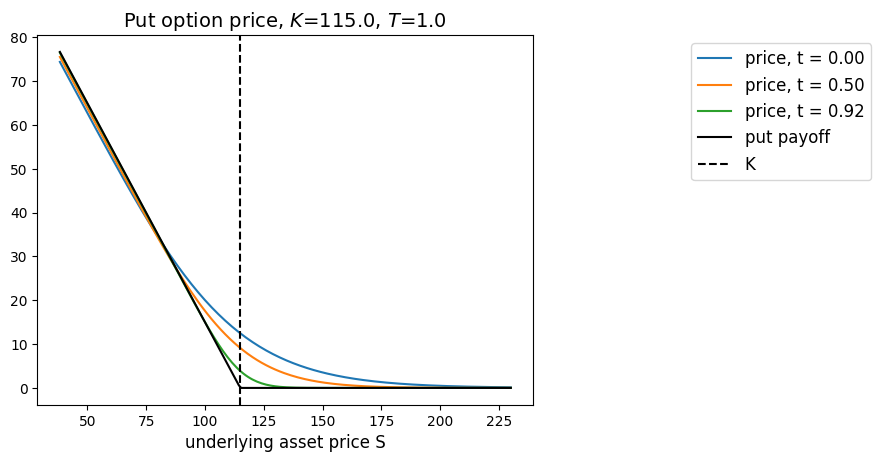

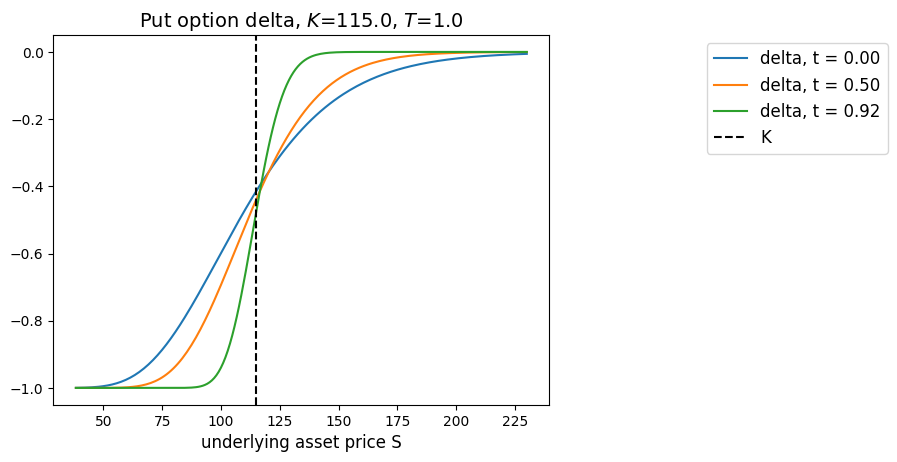

In [ ]:
#########
## price
#########

plt.figure()

for i in range(number_dates):
    plt.plot(S, price[i], label="price, t = %1.2f" % dates[i])

# Also plot the option payoff
plt.plot(S, np.maximum(K - S, 0), label="put payoff", color="k")
plt.axvline(K, color="k", linestyle="--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Put option price, $K$=%1.1f, $T$=%1.1f" % (K, maturity), fontsize=14)
plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)

#########
## delta
#########
plt.figure()

for i in range(number_dates):
    plt.plot(S, delta[i], label="delta, t = %1.2f" % dates[i])

plt.axvline(K, color="k", linestyle="--", label="K")
plt.xlabel("underlying asset price S", fontsize=12)
plt.title("Put option delta, $K$=%1.1f, $T$=%1.1f" % (K, maturity), fontsize=14)

plt.legend(loc=9, fontsize=12, bbox_to_anchor=(1.5, 1.0), ncol=1)
plt.show()